In [2]:
import pickle as pk
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer 

In [3]:
with open('reviews.pkl','rb') as file:
    df = pk.load(file)

df.head(5)

,GAME_ID,GAME_NAME,COMMENT,RATING,CMT_LEN
0,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,371 x 270 x 76 cm,8.5,20
1,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,I was favorably surprised by this I didnt buy ...,8.5,792
2,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,My favorite in the Pandemic Legacy series and ...,8.5,318
3,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,My favorite coop game,8.5,23
4,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,This is a must buy legacy game for anyone that...,8.5,131


In [4]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\Tucker
[nltk_data]     Rhodes\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [5]:
## Playing around for testing ##

sid = SentimentIntensityAnalyzer()
text = 'I hate NLTK!'
sentiment_scores = sid.polarity_scores(text)
print(sentiment_scores)

{'neg': 0.8, 'neu': 0.2, 'pos': 0.0, 'compound': -0.6114}


In [6]:
df['CMT_SENT'] = df.apply(lambda x: sid.polarity_scores(x['COMMENT'])['compound'],axis=1)

In [7]:
df.head(10)

,GAME_ID,GAME_NAME,COMMENT,RATING,CMT_LEN,CMT_SENT
0,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,371 x 270 x 76 cm,8.5,20,0.0000
1,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,I was favorably surprised by this I didnt buy ...,8.5,792,0.9751
2,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,My favorite in the Pandemic Legacy series and ...,8.5,318,0.9096
3,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,My favorite coop game,8.5,23,0.4588
4,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,This is a must buy legacy game for anyone that...,8.5,131,0.5106
5,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,First complete play through was awesome played...,8.5,97,0.9186
6,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,24 4,8.5,7,0.0000
7,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,Definitely one of my favorite games of all tim...,8.5,89,0.8271
8,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,This is my first legacy and campaign game and ...,8.5,608,0.8702
9,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,,8.5,1,0.0000


In [8]:
true_sent = df[df['CMT_SENT'] != 0]

In [9]:
true_sent.head(10)

,GAME_ID,GAME_NAME,COMMENT,RATING,CMT_LEN,CMT_SENT
1,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,I was favorably surprised by this I didnt buy ...,8.5,792,0.9751
2,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,My favorite in the Pandemic Legacy series and ...,8.5,318,0.9096
3,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,My favorite coop game,8.5,23,0.4588
4,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,This is a must buy legacy game for anyone that...,8.5,131,0.5106
5,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,First complete play through was awesome played...,8.5,97,0.9186
7,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,Definitely one of my favorite games of all tim...,8.5,89,0.8271
8,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,This is my first legacy and campaign game and ...,8.5,608,0.8702
10,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,Disassembled after played,8.5,25,0.3400
11,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,Just amazing Best game Ive played yet,8.5,40,0.8860
12,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,My 2024 Top 250 96\nMy 2023 Top 250 68\nMy 202...,8.5,142,0.8225


In [10]:
bad_sent = true_sent[true_sent['CMT_SENT'] < 0]

In [11]:
bad_sent.head()

,GAME_ID,GAME_NAME,COMMENT,RATING,CMT_LEN,CMT_SENT
28,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,One of the most overrated games Ive ever heard...,8.5,269,-0.7727
33,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,Good but as it grows it gets too chaotic addin...,8.5,135,-0.5187
37,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,DIFFICULTY MEDIUM,8.5,18,-0.3400
38,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,Bonn\nSob\nSchutte,8.5,19,-0.2500
79,535d74a6-b776-48d8-93ab-712be79763c7,Pandemic Legacy: Season 1,Apart from one or two good twists very generic...,8.5,172,-0.0972


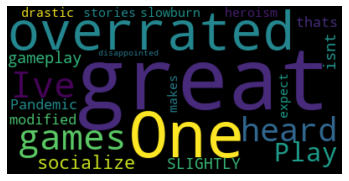

In [13]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt

wordcloud = WordCloud().generate(bad_sent['COMMENT'].loc[28])
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [18]:
## Explore use of nltk RAKE (Rapid Automatic Keyword Extraction) ##

from rake_nltk import Rake
from wordcloud import WordCloud

rake = Rake()

test = bad_sent['COMMENT'].loc[28]

rake.extract_keywords_from_text(test)
keywords = rake.get_ranked_phrases()

print(keywords)

['overrated games ive ever heard', 'slightly modified pandemic thats', 'would expect', 'great stories', 'great gameplay', 'drastic heroism', 'socialize', 'slowburn', 'play', 'one', 'makes', 'isnt', 'disappointed']


In [25]:
def get_key_phrases(text: str) -> list:

    rake.extract_keywords_from_text(text)
    keywords = rake.get_ranked_phrases()

    return keywords

In [26]:
df['KEY_PHRASES'] = df.apply(lambda x: get_key_phrases(x['COMMENT']),axis=1)

In [28]:
df

,GAME_ID,GAME_NAME,COMMENT,RATING,CMT_LEN,CMT_SENT,KEY_PHRASES
0,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,371 x 270 x 76 cm,8.5,20,0.0000,[371 x 270 x 76 cm]
1,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,I was favorably surprised by this I didnt buy ...,8.5,792,0.9751,"[consider somewhat mid im, also strikingly wel..."
2,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,My favorite in the Pandemic Legacy series and ...,8.5,318,0.9096,"[ive bought another copy, favorite legacy game..."
3,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,My favorite coop game,8.5,23,0.4588,[favorite coop game]
4,6c485b5a-283e-4f21-98cf-b058efcfe147,Pandemic Legacy: Season 1,This is a must buy legacy game for anyone that...,8.5,131,0.5106,"[must buy legacy game, cleanest legacy games, ..."
...,...,...,...,...,...,...,...
76343,3d5214d6-ec58-4d25-9b79-602e2a2d6387,Eldritch Horror,Fantastic game If you are looking for the evol...,7.8,354,0.7845,"[likely replace arkham horror, greatly look fo..."
76344,3d5214d6-ec58-4d25-9b79-602e2a2d6387,Eldritch Horror,Arkham Horror sprinkled with a chooseyourownad...,7.8,128,0.3384,"[world scale easy, chooseyourownadventure styl..."
76345,3d5214d6-ec58-4d25-9b79-602e2a2d6387,Eldritch Horror,Not really a boardgame in fact EH should be se...,7.8,210,0.8300,"[storytelling aspects cant see many, tabletop ..."
76346,3d5214d6-ec58-4d25-9b79-602e2a2d6387,Eldritch Horror,Watered down version of Arkham Horror Still ma...,7.8,168,0.6361,"[still provides enjoyment even, arkham horror ..."


In [35]:
pd.options.display.max_colwidth = 100
df['COMMENT'].sample(1)

28330    Love this game Long but splendid design Everything makes sense One of the few games where theme ...
Name: COMMENT, dtype: object

In [36]:
df = df[df['CMT_SENT'] != 0]

In [45]:
df = df[df['CMT_LEN'] > 0]

In [46]:
df.describe()

,CMT_LEN,CMT_SENT
count,59001.000000,59001.000000
mean,293.475941,0.568587
std,477.083898,0.456602
min,2.000000,-0.999900
25%,70.000000,0.425600
50%,159.000000,0.726400
75%,327.000000,0.897900
max,17870.000000,0.999800


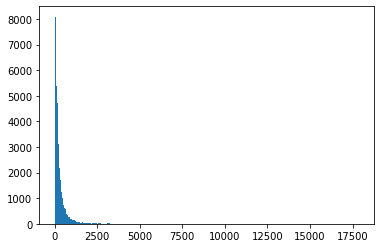

In [47]:
plt.hist(df['CMT_LEN'], bins = 500)
plt.axis('on')
plt.show()

Here are some findings from the above analysis:

- There are some comments in different languages. I will either need to translate those or remove them - although removing them might prove to be more difficult
- There are over 700 comments with 2000+ characters.
- Found use of RAKE to get key phrases. I think these will be most helpful in analyzing the comments and pulling out general truths about the games.
- Ultimately, I think I may need to consider all the text put together as one long text blob and do a word cloud that way. Of course, I would need to think of a way to remove the common words like "the", "and", and the like. But considering the comments altogether is the only way to pick up the common them accross all of them.
- Prior to doing this above, I'll likely split the dataset into positive and negative sentiment sets. This would make it more digestable for me as I analyze them further.

In [48]:
positive_sentiment = df[df['CMT_SENT'] > 0]
negative_sentiment = df[df['CMT_SENT'] < 0]

with open('pos_sent.pkl', 'wb') as file:
    pk.dump(positive_sentiment, file)

with open('neg_sent.pkl','wb') as file:
    pk.dump(negative_sentiment, file)